# TransferBench

# Experiment 6

## Vision Transformer (ViT-B16)

### Fine-Tuning

This notebook fine-tunes the last encoder block and classification head of ViT-B16.

Outputs

- Fine-Tuned Model
- Evaluation Metrics
- Learning Curves
- Confusion Matrix

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\pc1\TransferBench


In [2]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from utils.dataset import load_dataset

from utils.models import build_model

from utils.training import (
    train_model,
    print_summary,
)

from utils.evaluation import (
    calculate_metrics,
    print_metrics,
    export_metrics_csv,
    build_confusion_matrix,
)

from utils.visualization import (
    plot_loss_curve,
    plot_accuracy_curve,
    plot_confusion_matrix,
)

from utils.paths import *

Import OK ✅


In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Load Dataset

In [4]:
train_loader, test_loader, class_names = load_dataset(
    dataset_name="cifar10",
    batch_size=32,
    image_size=224,
)

C:\Users\pc1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Build ViT-B16

In [5]:
model = build_model(
    model_name="vit",
    num_classes=10,
    strategy="finetune",
)

model = model.to(device)

print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine

## Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),
    lr=1e-4,
)

optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)

In [7]:
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [8]:
EPOCHS = 20

checkpoint_path = get_model_path(
    "best_vit_finetune"
)

print(checkpoint_path)

C:\Users\pc1\TransferBench\models\best_vit_finetune.pth


## Train Model

In [9]:
results = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=checkpoint_path,
)

Training Started
Epoch 01/20 | Train Loss: 0.1797 | Train Acc: 0.9439 | Val Loss: 0.1320 | Val Acc: 0.9540
Epoch 02/20 | Train Loss: 0.0992 | Train Acc: 0.9673 | Val Loss: 0.1252 | Val Acc: 0.9583
Epoch 03/20 | Train Loss: 0.0707 | Train Acc: 0.9758 | Val Loss: 0.1148 | Val Acc: 0.9607
Epoch 04/20 | Train Loss: 0.0505 | Train Acc: 0.9825 | Val Loss: 0.1124 | Val Acc: 0.9658
Epoch 05/20 | Train Loss: 0.0377 | Train Acc: 0.9872 | Val Loss: 0.1195 | Val Acc: 0.9631
Epoch 06/20 | Train Loss: 0.0261 | Train Acc: 0.9907 | Val Loss: 0.1216 | Val Acc: 0.9662
Epoch 07/20 | Train Loss: 0.0214 | Train Acc: 0.9929 | Val Loss: 0.1347 | Val Acc: 0.9639
Epoch 08/20 | Train Loss: 0.0171 | Train Acc: 0.9943 | Val Loss: 0.1390 | Val Acc: 0.9635
Epoch 09/20 | Train Loss: 0.0131 | Train Acc: 0.9956 | Val Loss: 0.1365 | Val Acc: 0.9668
Epoch 10/20 | Train Loss: 0.0123 | Train Acc: 0.9955 | Val Loss: 0.1474 | Val Acc: 0.9649
Epoch 11/20 | Train Loss: 0.0123 | Train Acc: 0.9959 | Val Loss: 0.1503 | Val Acc: 

## Evaluation

In [10]:
metrics = calculate_metrics(
    results["targets"],
    results["predictions"],
)

print_metrics(metrics)

Evaluation Results
Accuracy  : 0.9693
Precision : 0.9694
Recall    : 0.9693
F1 Score  : 0.9693


In [11]:
metrics_df = export_metrics_csv(
    metrics=metrics,
    model_name="ViT-B16",
    strategy="Fine-Tuning",
    training_time=results["training_time"],
    save_path=get_metrics_path("vit_finetune"),
)

metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,ViT-B16,Fine-Tuning,0.9693,0.969445,0.9693,0.969322,11270.475773


## Learning Curves

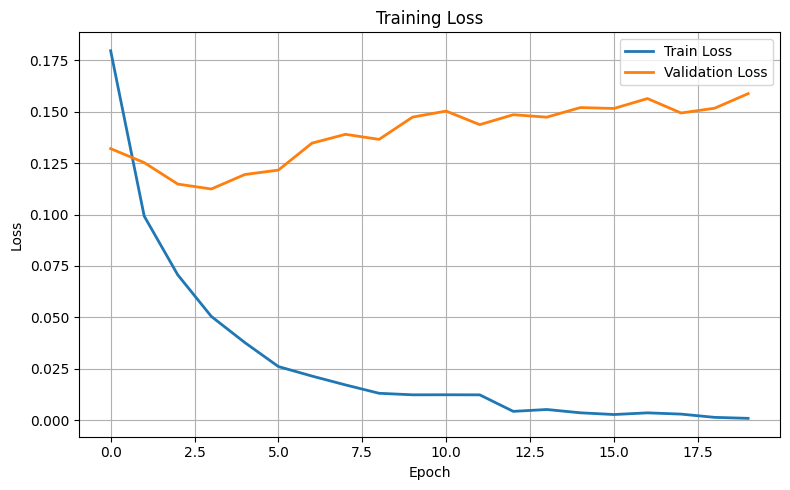

In [12]:
plot_loss_curve(
    history=results["history"],
    save_path=get_loss_plot_path("vit_finetune"),
)

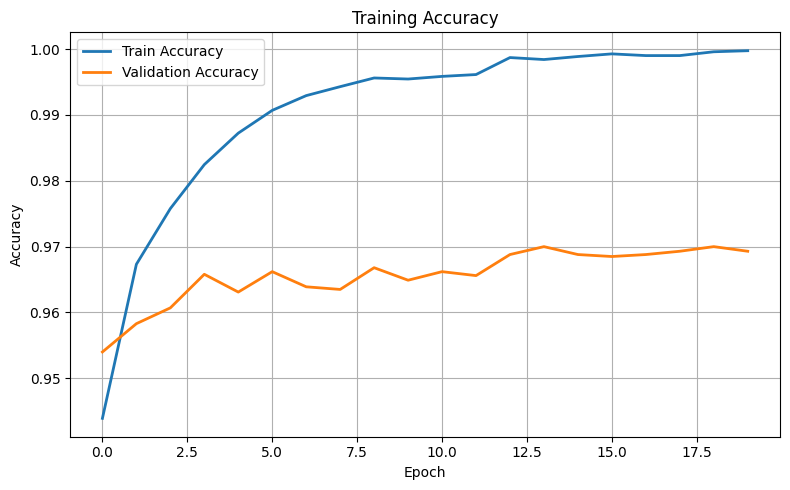

In [13]:
plot_accuracy_curve(
    history=results["history"],
    save_path=get_accuracy_plot_path("vit_finetune"),
)

## Confusion Matrix

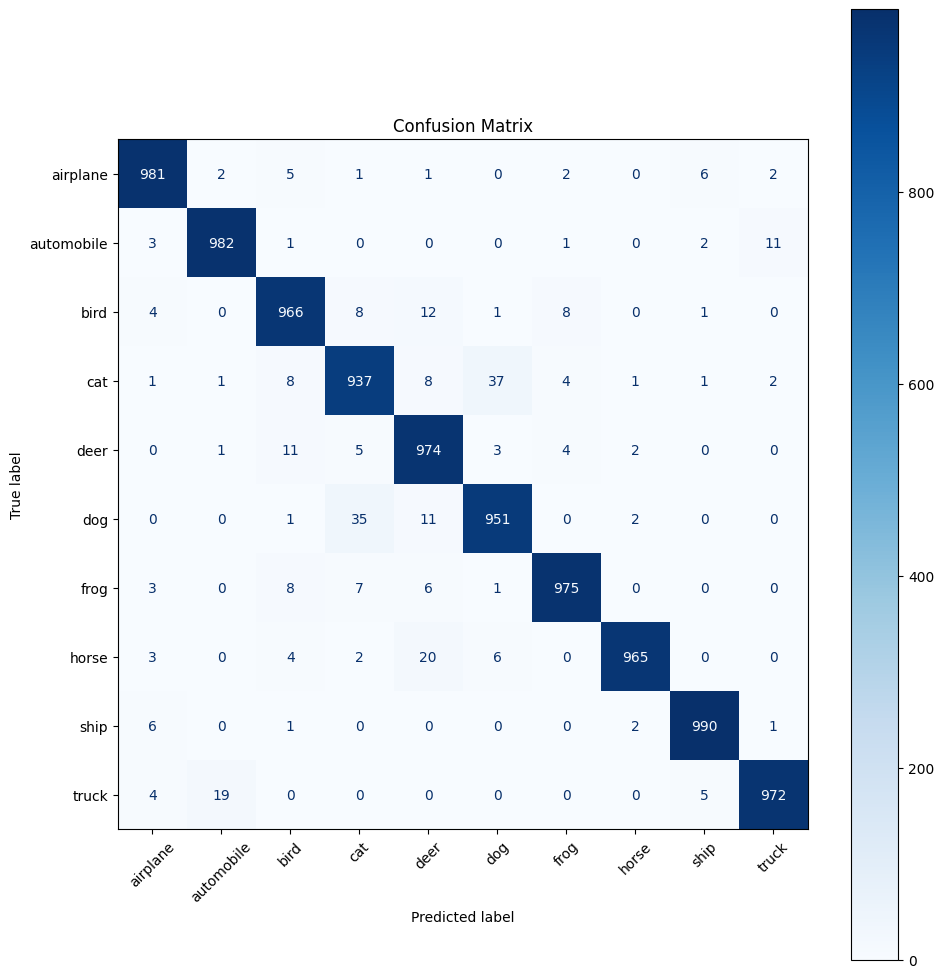

In [14]:
cm = build_confusion_matrix(
    results["targets"],
    results["predictions"],
)

plot_confusion_matrix(
    matrix=cm,
    class_names=class_names,
    save_path=get_confusion_matrix_path("vit_finetune"),
)

## Training Summary

In [15]:
print_summary(results)



Training Summary
Best Accuracy : 0.9700
Training Time : 11270.48 sec
Checkpoint    : C:\Users\pc1\TransferBench\models\best_vit_finetune.pth


In [16]:
metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,ViT-B16,Fine-Tuning,0.9693,0.969445,0.9693,0.969322,11270.475773


In [17]:
results["history"]

{'train_loss': [0.17965653429597617,
  0.09923256400778889,
  0.07066420919589698,
  0.05045381553089246,
  0.03772037790415809,
  0.026065798992235212,
  0.021438703057477252,
  0.017143209993271156,
  0.013073904737767298,
  0.01232353987150942,
  0.012346987073833006,
  0.012311594102593955,
  0.004275806669663288,
  0.00518672400198062,
  0.0035823484719227417,
  0.0027404454240531778,
  0.003556757646703918,
  0.0029486803026439155,
  0.0013627930321729218,
  0.0008868222622413304],
 'train_acc': [0.94392,
  0.96732,
  0.97578,
  0.98246,
  0.98724,
  0.9907,
  0.99294,
  0.9943,
  0.99562,
  0.99546,
  0.99586,
  0.99614,
  0.99872,
  0.99842,
  0.99888,
  0.99928,
  0.99902,
  0.99902,
  0.9996,
  0.99976],
 'val_loss': [0.13202832468301057,
  0.12524979516640306,
  0.1148087064050138,
  0.1124065647283569,
  0.11946015599016101,
  0.12160541536654346,
  0.13470227819252759,
  0.13899454257357866,
  0.13653607873811852,
  0.1473776809398929,
  0.15030349028164638,
  0.1436969771

In [18]:
results

{'history': {'train_loss': [0.17965653429597617,
   0.09923256400778889,
   0.07066420919589698,
   0.05045381553089246,
   0.03772037790415809,
   0.026065798992235212,
   0.021438703057477252,
   0.017143209993271156,
   0.013073904737767298,
   0.01232353987150942,
   0.012346987073833006,
   0.012311594102593955,
   0.004275806669663288,
   0.00518672400198062,
   0.0035823484719227417,
   0.0027404454240531778,
   0.003556757646703918,
   0.0029486803026439155,
   0.0013627930321729218,
   0.0008868222622413304],
  'train_acc': [0.94392,
   0.96732,
   0.97578,
   0.98246,
   0.98724,
   0.9907,
   0.99294,
   0.9943,
   0.99562,
   0.99546,
   0.99586,
   0.99614,
   0.99872,
   0.99842,
   0.99888,
   0.99928,
   0.99902,
   0.99902,
   0.9996,
   0.99976],
  'val_loss': [0.13202832468301057,
   0.12524979516640306,
   0.1148087064050138,
   0.1124065647283569,
   0.11946015599016101,
   0.12160541536654346,
   0.13470227819252759,
   0.13899454257357866,
   0.13653607873811852,

## Generated Files

In [19]:
print("=" * 60)

print("Saved Model")
print(get_model_path("best_vit_finetune"))

print()

print("Metrics CSV")
print(get_metrics_path("vit_finetune"))

print()

print("Loss Curve")
print(get_loss_plot_path("vit_finetune"))

print()

print("Accuracy Curve")
print(get_accuracy_plot_path("vit_finetune"))

print()

print("Confusion Matrix")
print(get_confusion_matrix_path("vit_finetune"))

print("=" * 60)

Saved Model
C:\Users\pc1\TransferBench\models\best_vit_finetune.pth

Metrics CSV
C:\Users\pc1\TransferBench\results\vit_finetune_metrics.csv

Loss Curve
C:\Users\pc1\TransferBench\figures\vit_finetune_loss.png

Accuracy Curve
C:\Users\pc1\TransferBench\figures\vit_finetune_accuracy.png

Confusion Matrix
C:\Users\pc1\TransferBench\figures\confusion_matrix_vit_finetune.png


In [20]:
from pathlib import Path

print("========== MODELS ==========")
for f in sorted(Path(MODEL_DIR).glob("*")):
    print(f.name)

print("\n========== FIGURES ==========")
for f in sorted(Path(FIGURE_DIR).glob("*")):
    print(f.name)

print("\n========== RESULTS ==========")
for f in sorted(Path(RESULT_DIR).glob("*")):
    print(f.name)

========== MODELS ==========
best_efficientnet_finetune.pth
best_efficientnet_freeze.pth
best_resnet18.pth
best_resnet18_finetune.pth
best_vit_finetune.pth
best_vit_freeze.pth

========== FIGURES ==========
.ipynb_checkpoints
confusion_matrix_efficientnet_finetune.png
confusion_matrix_efficientnet_freeze.png
confusion_matrix_resnet18.png
confusion_matrix_resnet18_finetune.png
confusion_matrix_vit_finetune.png
confusion_matrix_vit_freeze.png
dataset_samples.png
efficientnet_finetune_accuracy.png
efficientnet_finetune_loss.png
efficientnet_freeze_accuracy.png
efficientnet_freeze_loss.png
resnet18_accuracy.png
resnet18_finetune_accuracy.png
resnet18_finetune_loss.png
resnet18_loss.png
vit_finetune_accuracy.png
vit_finetune_loss.png
vit_freeze_accuracy.png
vit_freeze_loss.png

========== RESULTS ==========
efficientnet_finetune_metrics.csv
efficientnet_freeze_metrics.csv
resnet18_finetune_metrics.csv
resnet18_metrics.csv
vit_finetune_metrics.csv
vit_freeze_metrics.csv
